In [20]:
from _import_scripts import scripts
from scripts.notebook_utils import *
from scripts.tl_output_parsing import MacroOutputStats
from scripts.utils import *
import yaml

def create_layer_directory(base_output_dir: str, architecture: str, layer: int) -> str:
    layer_dir = os.path.join(base_output_dir, f"{architecture}_layer_{layer}")
    if not os.path.exists(layer_dir):
        os.makedirs(layer_dir)
    return layer_dir

num_layers = 1

def run_map(
    spec: tl.Specification,
    arch: str,
    accelergy_verbose: bool = False,
) -> dict:
    output_dir = get_run_dir()
    # Just use the directory name if it causes error
    base_output_dir = os.path.dirname(output_dir)
    base_output_dir = os.path.join(base_output_dir, arch)
    global num_layers

    mapper_result = None

    if num_layers < 17:
        # Create a directory for the current layer
        layer_dir = create_layer_directory(base_output_dir, arch, num_layers)
        # print(f"Layer directory: {layer_dir}")
        num_layers += 1

        run_prefix = f"{layer_dir}/timeloop-mapper"
        mapper_result = tl.call_mapper(
            specification=spec,
            output_dir=layer_dir,
            log_to=os.path.join(output_dir, f"{run_prefix}.log"),
        )
        if accelergy_verbose:
            tl.call_accelergy_verbose(
                specification=spec,
                output_dir=layer_dir,
                log_to=os.path.join(output_dir, "accelergy.log"),
            )

    if mapper_result is None:
        # Handle case when mapper_result is not assigned (num_layers >= 17)
        # Raise an error, return a default value
        print("Warning: mapper_result is not assigned. num_layers >= 17")
        return {}

    return MacroOutputStats.from_output_stats(mapper_result)

import re

def extract_range(line):
    match = re.search(r'\[(\d+):(\d+)(,\d+)?\)', line)
    if match:
        start = int(match.group(1))
        end = int(match.group(2))
        return end - start
    return None

def read_and_compute_multiplication(filename, i):
    filename = f"../outputs/{filename}/{filename}_layer_{i+1}/timeloop-mapper.map.txt"
    with open(filename, 'r') as file:
        lines = file.readlines()

    start_searching = False
    ranges = []

    for line in lines:
        # Start searching when 'inter_macro_in_system_spatial' is found
        if "inter_macro_in_system_spatial" in line:
            start_searching = True
        
        # Stop searching if we leave the 'inter_macro_in_system_spatial' section
        elif start_searching and "inter_" in line and "inter_macro_in_system_spatial" not in line:
            break

        # If we are in the 'inter_macro_in_system_spatial' section, look for the ranges
        if start_searching:
            if "for" in line:
                range_size = extract_range(line)
                if range_size is not None:
                    ranges.append(range_size)
            elif line.strip() == "":  # Exit the section on an empty line
                break

    # Compute the multiplication of all ranges, or return 1 if no ranges were found
    if not ranges:
        print(f"All macro: 1")
        return 1

    result = 1
    for size in ranges:
        result *= size
        print(f"Size: {size}")
    print(f"All macro: {result}")
    return result


def extract_layer_number(folder_name):
    match = re.search(r'layer_(\d+)', folder_name)
    return int(match.group(1)) if match else float('inf')

def extract_outputs(model):
    
    output_dir = "../outputs/" + model + "/" 
    print(output_dir)

    print ("Model \t Energy/inference (J) \t Area (mm2) \t Throughput (inf/s)")
    #for model in models:    
    throughput = 0   
    energy = 0
    area = 0
    cycles = 0
    folders = sorted([folder for folder in os.listdir(output_dir) if model in folder], key=extract_layer_number)
    area_per_many_macro = 0
    area_layer = 0
    j = 0
    total_sum = 0
    total_adc_area = 0  # Total area for ADC across all layers
    total_other_areas = {}  # Dictionary to store total areas for other components
    total_col_area = 0
    total_row_area = 0
    total_cim_unit_area = 0
    total_area = 0
    total_macro = 0
    
    for folder in folders:
        total = 0
        if model in folder:
            print(f"Processing layer: {folder}")
            # print(folder)
            if os.path.isdir(output_dir + folder):
                stat_file = output_dir + folder + "/timeloop-mapper.stats.txt"
                art_file = output_dir + folder + "/timeloop-mapper.ART.yaml"
        
                with open(stat_file, 'r') as f:
                    energy_stat = [line for line in f if line.startswith("Energy:")][0]
                    energy_uj = energy_stat.split(' ')[1] # uJ
                    energy += float(energy_uj)
                    # print(f"Energy for this layer: {float(energy_uj)} uj")
                
                with open(stat_file, 'r') as f:
                    cycle_stat = [line for line in f if line.startswith("Cycles:")][0]                  
                    cycle = cycle_stat.split(' ')[1] 
                    cycles += float(cycle)
                    
            if j < 16:
                with open(art_file, 'r') as file:
                    data = yaml.safe_load(file)
                
                    # Extract and print the name, area, number of entries, and ratio for non-zero areas
                for table in data['ART']['tables']:
                    name = table.get('name')
                    area = table.get('area')
                    if area != 0:
                        # Simplify the name for the output
                        if 'system_top_level.' in name:
                            name = name.split('system_top_level.')[-1]
                        
                        # Extract the number of entries from the name
                        if '[' in name:
                            name_part, entries_part = name.split('[')
                            number_of_entries = entries_part.split('..')[1].replace(']', '')
                            name = name_part.strip()
                        else:
                            number_of_entries = 'Unknown'
                        
                        macro = read_and_compute_multiplication(model, j)
                        # Calculate total ratio
                        if number_of_entries != 'Unknown' and number_of_entries.isdigit():
                            total_ratio = (area / 4096) * macro * int(number_of_entries)
                        else:
                            total_ratio = 0
                        
                        total += total_ratio
                           
                        # Accumulate area for ADC or other components
                        if 'adc' in name.lower():
                            total_adc_area += total_ratio
                        else:
                            if name not in total_other_areas:
                                total_other_areas[name] = 0
                            total_other_areas[name] += total_ratio
            
                        print(f"{name.replace('_', ' ')} area: {area}, number of {name}: {number_of_entries}, \ntotal {name.replace('_', ' ')} area: ({area}*{number_of_entries}/4096) * macro = {total_ratio}\n")
                j += 1 
                total_sum += total
                total_macro += macro
                print(f"Total Area for layer {j}: {total}\n")
                print(f"Total Macro for layer {j}: {total_macro}\n")
            print(f"Total Area for all layers: {total_sum}")
            print(f"Total Area for ADC across all layers: {total_adc_area}")
    
    # Print total area for other components
    for component, area in total_other_areas.items():
        print(f"Total Area for {component.replace('_', ' ')} across all layers: {area}")
        # print(component.replace('_', ' '))
        if component.replace('_', ' ') ==  "column drivers":
            total_col_area = area
        elif component.replace('_', ' ') ==  "row drivers":
            total_row_area = area
        else:
            total_cim_unit_area = area
                                
    energy *= 1e-6 # conver to J
    total_area = total_sum * 1e-6 # mm2
    throughput = 1 / (cycles * 1e-7) # s

    total_adc_area = total_adc_area * 1e-6 # mm2
    total_col_area = total_col_area * 1e-6 # mm2
    total_row_area = total_row_area * 1e-6 # mm2
    total_cim_unit_area = total_cim_unit_area * 1e-6 # mm2
    print("\n")
    print(f"Total Area for ADC across all layers: {total_adc_area}")
    print(f"Total Area for column driver across all layers: {total_col_area}")
    print(f"Total Area for row driver across all layers: {total_row_area}")
    print(f"Total Area for cim unit across all layers: {total_cim_unit_area}")
    print(f"Total Macro across all layers: {total_macro}")
    print ("{} \t {:.2e} \t {:.2f} \t {:.2e}".format(model, energy, total_area, throughput))
    
    return total_area, total_adc_area, total_col_area, total_row_area, total_cim_unit_area, total_macro, energy, throughput




Running vgg16 with 32 x 32 SRAM with 22 nm 
Layer directory: /home/workspace/scripts/../outputs/SRAM_vgg16_32/SRAM_vgg16_32_layer_1
Computes for layer 1: 169344.0
Layer directory: /home/workspace/scripts/../outputs/SRAM_vgg16_32/SRAM_vgg16_32_layer_2
Computes for layer 2: 3612672.0
Layer directory: /home/workspace/scripts/../outputs/SRAM_vgg16_32/SRAM_vgg16_32_layer_3
Computes for layer 3: 1806336.0
Layer directory: /home/workspace/scripts/../outputs/SRAM_vgg16_32/SRAM_vgg16_32_layer_4
Computes for layer 4: 3612672.0
Layer directory: /home/workspace/scripts/../outputs/SRAM_vgg16_32/SRAM_vgg16_32_layer_5
Computes for layer 5: 1806336.0
Layer directory: /home/workspace/scripts/../outputs/SRAM_vgg16_32/SRAM_vgg16_32_layer_6
Computes for layer 6: 3612672.0
Layer directory: /home/workspace/scripts/../outputs/SRAM_vgg16_32/SRAM_vgg16_32_layer_7
Computes for layer 7: 3612672.0
Layer directory: /home/workspace/scripts/../outputs/SRAM_vgg16_32/SRAM_vgg16_32_layer_8
Computes for layer 8: 180633

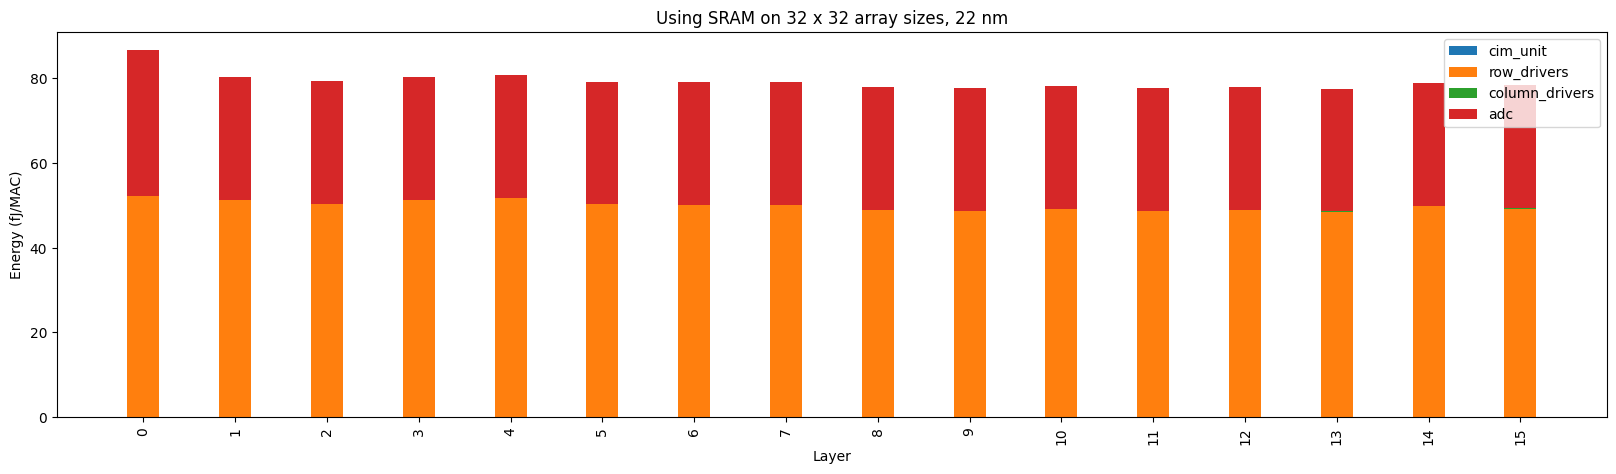

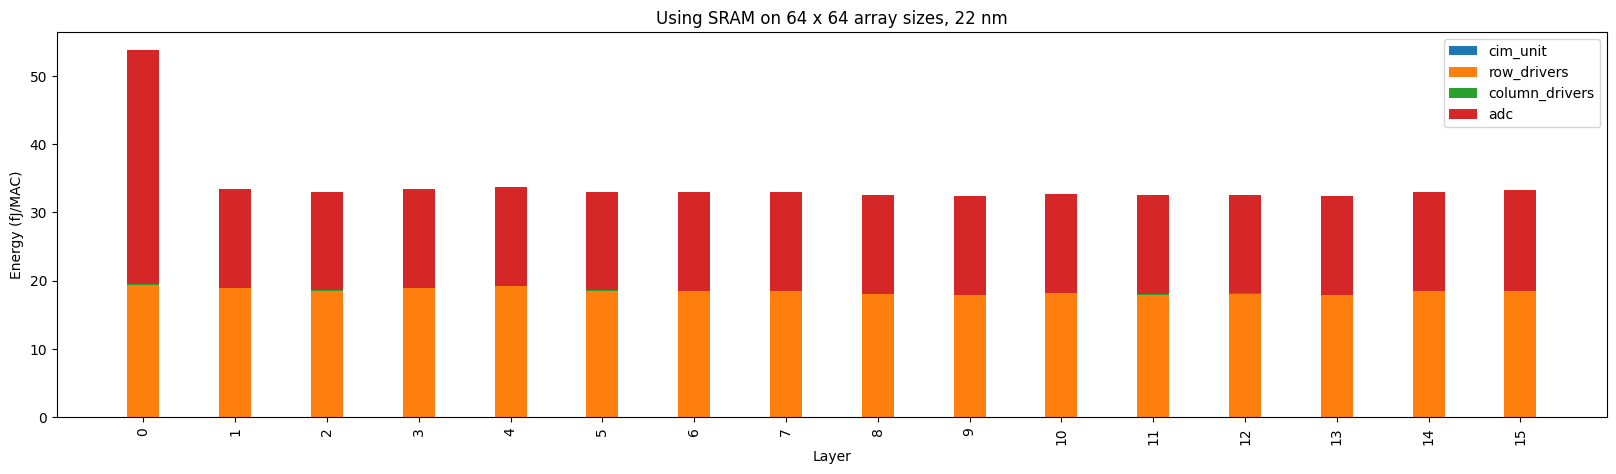

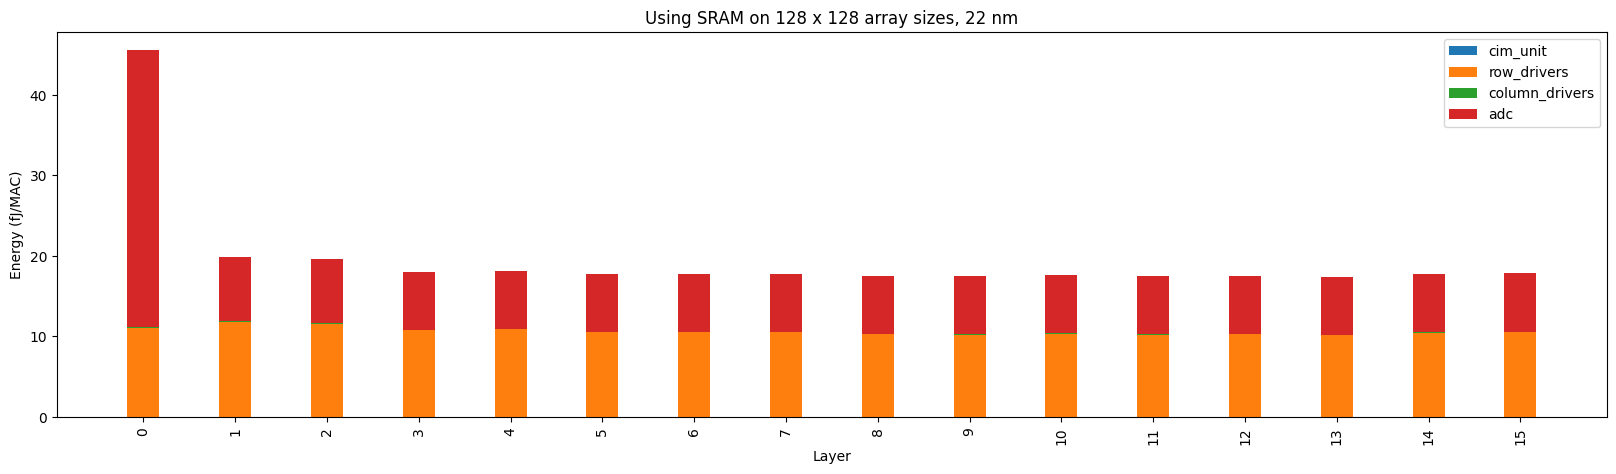

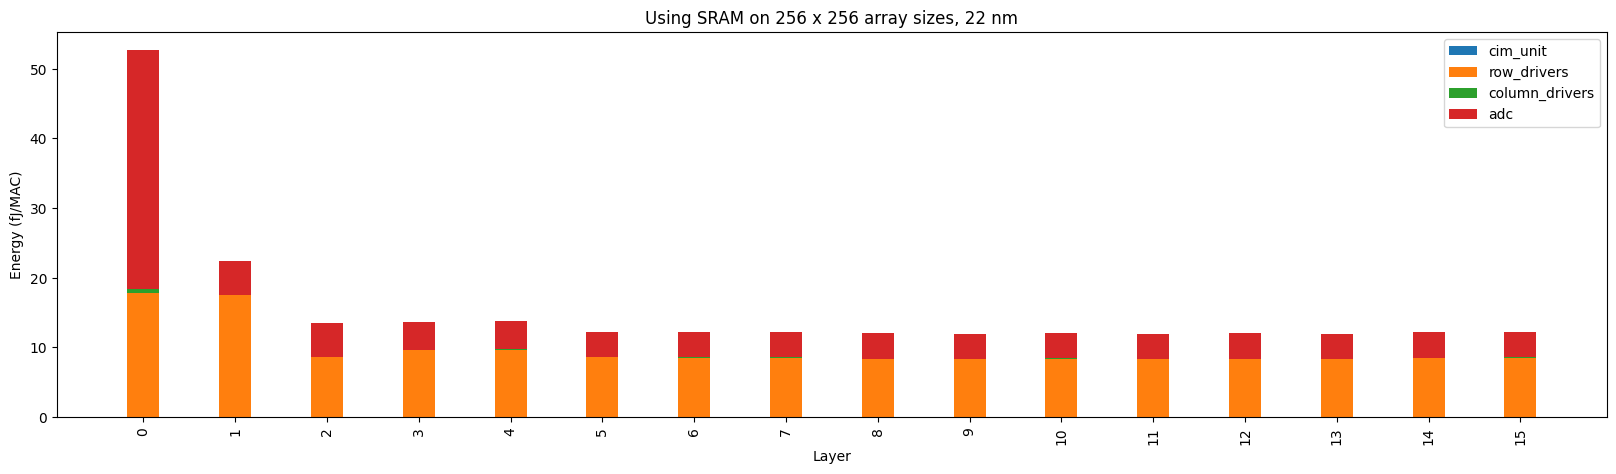

In [4]:
MACRO_PATH = "../models/arch/1_macro/basic_analog/" 
macro = {}
SRAM_PATH = f'"{os.path.abspath("../models/memory_cells/sram_example.cell.yaml")}"'
RRAM_PATH = f'"{os.path.abspath("../models/memory_cells/rram_example.cell.yaml")}"'

# Define the architecture
array_sizes_list = [32, 64, 128, 256]
path = SRAM_PATH
tech_node = 22
adc_resolution = 5
DNN = "vgg16"

total_per_energy = {}

for array_sizes in array_sizes_list:
    arch = f"{path.split('/')[-1].split('_')[0].upper()}_{DNN}_{array_sizes}"
    print(f"\nRunning {DNN} with {array_sizes} x {array_sizes} {path.split('/')[-1].split('_')[0].upper()} with {tech_node} nm ")

    num_layers = 1

    def run_dnn(dnn: str, layer: str, array_sizes: int, variables):
        print(f"{layer} ", end="", flush=True)
        spec = get_spec(
            "basic_analog",
            # Weight-stationary, dummy buffer on top to hold inputs & outputs, many
            # macros to ensure we can fit all weights.
            system="ws_dummy_buffer_many_macro",
            # Set the DNN and layer
            dnn=dnn,
            layer=layer,
        )
    
        # Do NOT generate a maximum-utilization workload; we're running a DNN
        # workload.
        spec.variables["MAX_UTILIZATION"] = False
    
        # Use a larger array to ensure we can fit all weights
        spec.architecture.find("column").spatial.meshX = array_sizes
        spec.architecture.find("row").spatial.meshY = array_sizes
    
        spec.variables.update(variables)
        output_stats = run_map(spec, arch)
        
        # Print computes for the layer
        macro_output_stats = MacroOutputStats.from_output_stats(output_stats)
        print(f"Computes for layer {int(layer) + 1}: {macro_output_stats.computes}")
        global macro
        macro[layer] = macro_output_stats.computes
        return output_stats
    
    layers = [f for f in os.listdir(f"../models/workloads/{DNN}") if f != "index.yaml" and f.endswith(".yaml")]
    layers = sorted(layers)
    print(f"Running: ", end="")
    
    # Parallel/Delayed is used to multiprocess. Equivalent to running the following
    # code in serial:
    results = joblib.Parallel(n_jobs=None)(
        joblib.delayed(run_dnn)(DNN, layer.split(".")[0], array_sizes, 
                                  {
                                      "CELL_CONFIG": path,
                                      "BITS_PER_CELL": 1 if path == SRAM_PATH else 4,
                                      "CIM_UNIT_WIDTH_CELLS": 4 if path == SRAM_PATH else 1,
                                      "IS_SRAM": path == SRAM_PATH,
                                      "TECHNOLOGY": tech_node,
                                      "ADC_RESOLUTION": adc_resolution
                                  }
                                 ) for layer in layers
    )
    print("")
    for r in results:
        r.clear_zero_energies()
    
    #Initialize overall_energy
    energy_layer = [0] * 16
    result = 0
    
    # total_per_energy_32 = [0] * 4
    
    total_adc_energy = 0.0
    total_col_energy = 0.0
    total_row_energy = 0.0
    total_cim_unit_energy = 0.0
    # Calculate overall energy
    for r in results:
    
        per_component_energy = r.per_compute("per_component_energy")
        total_energy_per_layer = sum(per_component_energy.values()) * 1e15  # Convert to fJ
        total_adc_energy += per_component_energy.get('adc', 0.0)
        total_col_energy += per_component_energy.get('column_drivers', 0.0)
        total_row_energy += per_component_energy.get('row_drivers', 0.0)
        total_cim_unit_energy += per_component_energy.get('cim_unit', 0.0)
    
        total_adc_energy = total_adc_energy * 1e15
        total_col_energy = total_col_energy * 1e15
        total_row_energy = total_row_energy * 1e15
        total_cim_unit_energy = total_cim_unit_energy * 1e15
        total_energy = total_adc_energy + total_col_energy + total_row_energy + total_cim_unit_energy
    
        total_adc_energy = total_adc_energy/total_energy
        total_col_energy = total_col_energy/total_energy
        total_row_energy = total_row_energy/total_energy
        total_cim_unit_energy = total_cim_unit_energy/total_energy
      
        # total_per_energy_32[0] = total_adc_energy
        # total_per_energy_32[1] = total_col_energy
        # total_per_energy_32[2] = total_row_energy
        # total_per_energy_32[3] = total_cim_unit_energy

        total_per_energy[array_sizes] = [total_adc_energy, total_col_energy, total_row_energy, total_cim_unit_energy]
        
    # Display overall energy
    print(f"Overall energy for DNN {DNN}: {total_energy} fJ")
    
    # Display an energy breakdown for each layer as a bar chart. Display normalized per-MAC and per-layer energy.
    fig, ax = plt.subplots(figsize=(20, 5))
    
    bar_stacked(
        {i: r.per_compute("per_component_energy") * 1e15 for i, r in enumerate(results)},
        title= f"Using {path.split('/')[-1].split('_')[0].upper()} on {array_sizes} x {array_sizes} array sizes, {tech_node} nm",
        xlabel="Layer",
        ylabel="Energy (fJ/MAC)",
        ax=ax,
    )

In [7]:
display_markdown(
    """
### Calculating Area

"""
)
total_area = [0] * 4
total_adc_area = [0] * 4
total_col_area = [0] * 4
total_row_area = [0] * 4
total_cim_unit_area = [0] * 4
total_macro = [0] * 4
energy = [0] * 4
throughput = [0] * 4
total_area[0], total_adc_area[0], total_col_area[0], total_row_area[0], total_cim_unit_area[0], total_macro[0], energy[0], throughput[0] = extract_outputs("SRAM_vgg16_32")
total_area[1], total_adc_area[1], total_col_area[1], total_row_area[1], total_cim_unit_area[1], total_macro[1], energy[1], throughput[1] = extract_outputs("SRAM_vgg16_64")
total_area[2], total_adc_area[2], total_col_area[2], total_row_area[2], total_cim_unit_area[2], total_macro[2], energy[2], throughput[2] = extract_outputs("SRAM_vgg16_128")
total_area[3], total_adc_area[3], total_col_area[3], total_row_area[3], total_cim_unit_area[3], total_macro[3], energy[3], throughput[3] = extract_outputs("SRAM_vgg16_256")


### Calculating Area



../outputs/SRAM_vgg16_32/
Model 	 Energy/inference (J) 	 Area (mm2) 	 Throughput (inf/s)
Processing layer: SRAM_vgg16_32_layer_1
Size: 4
All macro: 4
adc area: 12441.5, number of adc: 4096, 
total adc area: (12441.5*4096/4096) * macro = 49766.0

Size: 4
All macro: 4
column drivers area: 34.1833, number of column_drivers: 4096, 
total column drivers area: (34.1833*4096/4096) * macro = 136.7332

Size: 4
All macro: 4
row drivers area: 126.56, number of row_drivers: 4096, 
total row drivers area: (126.56*4096/4096) * macro = 506.24

Size: 4
All macro: 4
cim unit area: 0.15488, number of cim_unit: 4194304, 
total cim unit area: (0.15488*4194304/4096) * macro = 634.38848

Total Area for layer 1: 51043.36168

Total Macro for layer 1: 4

Total Area for all layers: 51043.36168
Total Area for ADC across all layers: 49766.0
Processing layer: SRAM_vgg16_32_layer_2
Size: 3
Size: 3
Size: 4
Size: 2
All macro: 72
adc area: 12441.5, number of adc: 4096, 
total adc area: (12441.5*4096/4096) * macro = 89

In [8]:
print(total_area)
print(total_adc_area)
print(total_col_area)
print(total_row_area)
print(total_cim_unit_area)
print(total_macro)
print(energy)
print(throughput)

[369.09454830807994, 255.12490174976003, 145.56026295648, 130.83260849639998]
[359.85794599999997, 238.48964159999997, 119.7810984, 76.63321799999999]
[0.9887177692, 2.0530491520000003, 3.47391864, 7.6937355]
[3.6606214399999994, 3.853433024, 3.28881684, 3.5702426700000003]
[4.587263098879999, 10.72877797376, 19.016429076479998, 42.9354123264]
[28924, 16912, 7494, 4230]
[0.001225431, 0.000512178, 0.00028297109999999995, 0.00021539409999999997]
[71.42346975216056, 72.56630746344473, 72.57210038172926, 72.5736804290556]


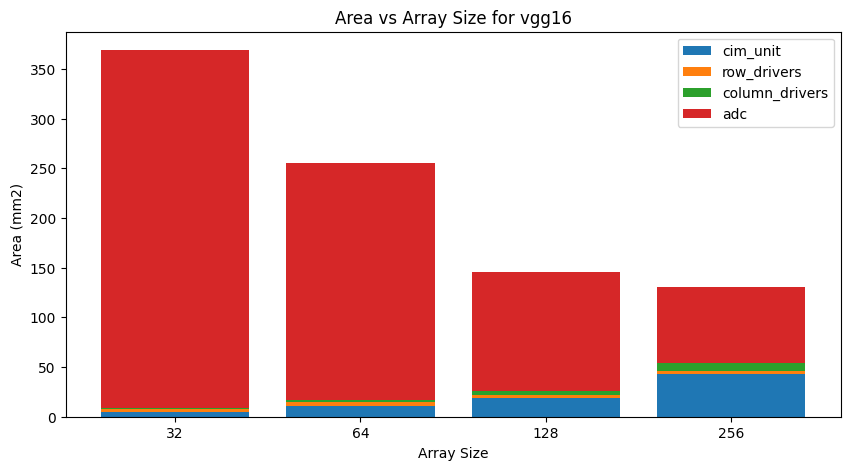

In [9]:
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize=(10, 5)) 
array_sizes = ['32', '64', '128', '256']

x = np.arange(len(array_sizes))

# Stack bars
ax.bar(array_sizes, total_cim_unit_area, label='cim_unit')
ax.bar(array_sizes, total_row_area, bottom=total_cim_unit_area, label='row_drivers')
ax.bar(array_sizes, total_col_area, bottom=np.array(total_cim_unit_area) + np.array(total_row_area), label='column_drivers')
ax.bar(array_sizes, total_adc_area, bottom=np.array(total_cim_unit_area) + np.array(total_row_area) + np.array(total_col_area), label='adc')

# Labels and title
ax.set_title("Area vs Array Size for vgg16")
ax.set_xlabel("Array Size")
ax.set_ylabel("Area (mm2)")
# Set x-ticks
ax.set_xticks(x)
ax.set_xticklabels(array_sizes)

ax.legend()

# Show plot
plt.show()

In [10]:
for array_size in array_sizes_list:
    print(f"Array size: {array_size}")
    # For each component index (0 to 3)
    for i in range(4):
        print(f"total_per_energy[{array_size}][{i}]: {total_per_energy[array_size][i]}")
    print() 

Array size: 32
total_per_energy[32][0]: 0.39600964135708533
total_per_energy[32][1]: 0.000703360407783485
total_per_energy[32][2]: 0.6028803495287823
total_per_energy[32][3]: 0.0004066487063488509

Array size: 64
total_per_energy[64][0]: 0.6380660693605413
total_per_energy[64][1]: 0.0022475163040162347
total_per_energy[64][2]: 0.35903120619257645
total_per_energy[64][3]: 0.0006552081428660541

Array size: 128
total_per_energy[128][0]: 0.7533185368079499
total_per_energy[128][1]: 0.0052957168781573825
total_per_energy[128][2]: 0.24061218936863277
total_per_energy[128][3]: 0.0007735569452599225

Array size: 256
total_per_energy[256][0]: 0.6516825080632851
total_per_energy[256][1]: 0.009162461531277819
total_per_energy[256][2]: 0.338485840009097
total_per_energy[256][3]: 0.0006691903963400809



In [16]:
display_markdown(
    """
### Calculating the energy

"""
)

total_adc_energy = [0] * 4
total_col_energy = [0] * 4
total_row_energy = [0] * 4
total_cim_unit_energy = [0] * 4
for j in range(len(energy)):
    if j == 0:
        for i in range(4):
            if i == 0:
                total_adc_energy[j] = total_per_energy[32][i] * energy[j]
            elif i == 1:
                total_col_energy[j] = total_per_energy[32][i] * energy[j]
            elif i == 2:
                total_row_energy[j] = total_per_energy[32][i] * energy[j]
            else:
                total_cim_unit_energy[j] = total_per_energy[32][i] * energy[j]
    elif j == 1:
        for i in range(4):
            if i == 0:
                total_adc_energy[j] = total_per_energy[64][i] * energy[j]
            elif i == 1:
                total_col_energy[j] = total_per_energy[64][i] * energy[j]
            elif i == 2:
                total_row_energy[j] = total_per_energy[64][i] * energy[j]
            else:
                total_cim_unit_energy[j] = total_per_energy[64][i] * energy[j]

    elif j == 2:
        for i in range(4):
            if i == 0:
                total_adc_energy[j] = total_per_energy[128][i] * energy[j]
            elif i == 1:
                total_col_energy[j] = total_per_energy[128][i] * energy[j]
            elif i == 2:
                total_row_energy[j] = total_per_energy[128][i] * energy[j]
            else:
                total_cim_unit_energy[j] = total_per_energy[128][i] * energy[j]

    else:
        for i in range(4):
            if i == 0:
                total_adc_energy[j] = total_per_energy[256][i] * energy[j]
            elif i == 1:
                total_col_energy[j] = total_per_energy[256][i] * energy[j]
            elif i == 2:
                total_row_energy[j] = total_per_energy[256][i] * energy[j]
            else:
                total_cim_unit_energy[j] = total_per_energy[256][i] * energy[j]
                
print("Total ADC Energy:", total_adc_energy)
print("Total Column Energy:", total_col_energy)
print("Total Row Energy:", total_row_energy)
print("Total CIM Unit Energy:", total_cim_unit_energy)


### Calculating the energy



Total ADC Energy: [0.0004852824908178544, 0.0003268034032729433, 0.00021316737501093604, 0.00014036856731003403]
Total Column Energy: [8.619196478705238e-07, 1.151128405558427e-06, 1.4985348303007603e-06, 1.973540155314207e-06]
Total Row Energy: [0.0007387882696034052, 0.0001838878851253014, 6.808629589905031e-05, 7.290785287150343e-05]
Total CIM Unit Energy: [4.983199308697787e-07, 3.355831961968498e-07, 2.1889425971284002e-07, 1.44139663148315e-07]


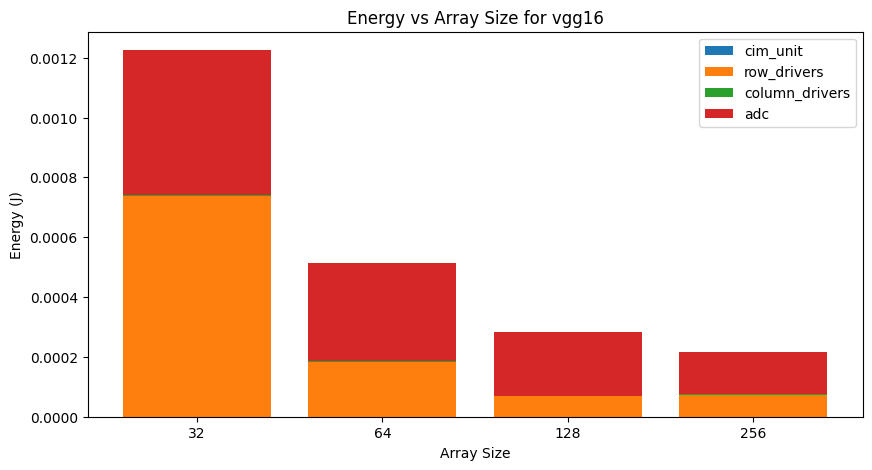

In [17]:
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize=(10, 5)) 
array_sizes = ['32', '64', '128', '256']

x = np.arange(len(array_sizes))

# Stack bars
ax.bar(array_sizes, total_cim_unit_energy, label='cim_unit')
ax.bar(array_sizes, total_row_energy, bottom=total_cim_unit_energy, label='row_drivers')
ax.bar(array_sizes, total_col_energy, bottom=np.array(total_cim_unit_energy) + np.array(total_row_energy), label='column_drivers')
ax.bar(array_sizes, total_adc_energy, bottom=np.array(total_cim_unit_energy) + np.array(total_row_energy) + np.array(total_col_energy), label='adc')

# Labels and title
ax.set_title("Energy vs Array Size for vgg16")
ax.set_xlabel("Array Size")
ax.set_ylabel("Energy (J)")
# Set x-ticks
ax.set_xticks(x)
ax.set_xticklabels(array_sizes)

ax.legend()

# Show plot
plt.show()


### Plot the Throughput



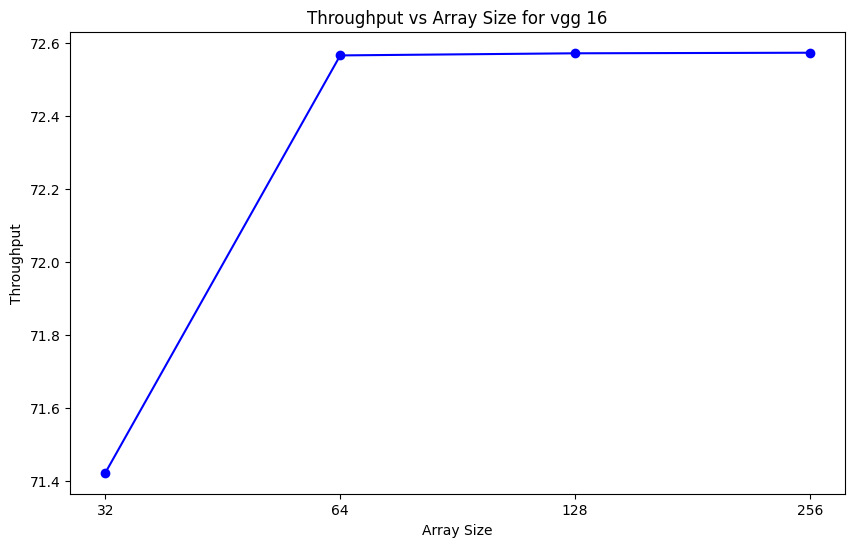

In [19]:
display_markdown(
    """
### Plot the Throughput

"""
)
import matplotlib.pyplot as plt

# Data
array_sizes = ['32', '64', '128', '256']
x = np.arange(len(array_sizes))
# Plotting the line graph
plt.figure(figsize=(10, 6))
plt.plot(array_sizes, throughput, marker='o', linestyle='-', color='b')

# Adding labels and title
plt.xlabel('Array Size')
plt.ylabel('Throughput')
plt.title('Throughput vs Array Size for vgg 16')
plt.grid(False)
plt.xticks(x, array_sizes) 
# Show plot
plt.show()


### Plot the Number of Macros



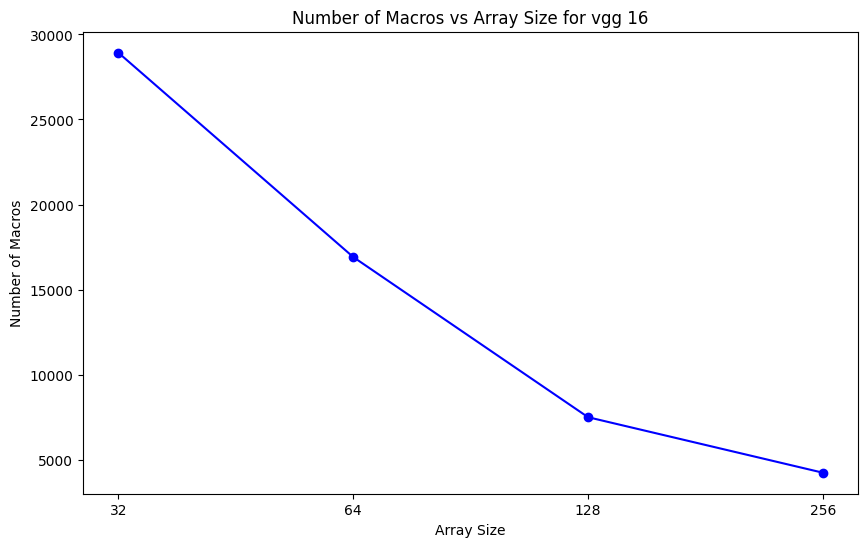

In [18]:
display_markdown(
    """
### Plot the Number of Macros

"""
)
import matplotlib.pyplot as plt

# Data
array_sizes = ['32', '64', '128', '256']
x = np.arange(len(array_sizes))
# Plotting the line graph
plt.figure(figsize=(10, 6))
plt.plot(array_sizes, total_macro, marker='o', linestyle='-', color='b')

# Adding labels and title
plt.xlabel('Array Size')
plt.ylabel('Number of Macros')
plt.title('Number of Macros vs Array Size for vgg 16')
plt.grid(False)
plt.xticks(x, array_sizes) 
# Show plot
plt.show()